# Breast Cancer Biomarker Discovery via LASSO Regression

**Dataset:** GSE15852: 43 breast cancer + 43 normal breast tissue transcriptomic profiles (Affymetrix U133 Plus 2.0).

**Objective:** Parse the GEO SOFT series matrix, verify sample alignment, standardise the expression matrix, and apply L1-regularised regression (LassoCV) to identify the most predictive gene probes for distinguishing cancer from normal tissue.

In [1]:
#impors, np , pd and plt are all standard as ofr sklearn funcs their usage will be discussed in their respectve part of the code.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LassoCV, Lasso
from sklearn.metrics import accuracy_score, classification_report

#strictly for model exportation for external dataset validation
import joblib

#used to leverage our knowledge of clear human error and try to remove this error in data
from combat.pycombat import pycombat

DATA_PATH = "data/GSE15852_series_matrix.txt"



## Data Parsing & Alignment Verification

We scan the metadata header line-by-line to extract three things:
- **Target labels (y):** from the `!Sample_characteristics_ch1` row containing `"tissue:"`
- **Matrix start line:** where the actual expression data begins

In [2]:
# parse metadata in a single pass through the file
y                 = None
matrix_start_line = None

with open(DATA_PATH, "r") as f:
    for line_num, line in enumerate(f, start=1):
        
        #locate row that starts with this string (target var indicator)
        if line.startswith("!Sample_source_name_ch1"):
            fields = line.strip().split("\t")[1:]          # skip row name
            labels = []

            #clean fields, then check if normal or tumor in v, append as 0 and 1 respectively
            for v in fields:
                v_clean = v.strip().strip('"').lower()
                if "normal" in v_clean:
                    labels.append(0)
                elif "tumor" in v_clean or "tumour" in v_clean or "cancer" in v_clean:
                    labels.append(1)
                else:
                    #error check
                    raise ValueError(
                        f"Unrecognised tissue label: '{v}'. "
                        "Expected 'normal breast tissue' or 'breast tumor tissue'."
                    )
            y = np.array(labels, dtype=int)

        # Matrix Start indicator, we use pd_read.csv for this later
        if line.startswith("!series_matrix_table_begin"):
            matrix_start_line = line_num
            break

#count of normal and abnormal should be perfectly 50/50
n_normal = int((y == 0).sum())
n_cancer = int((y == 1).sum())
print(f"Training dataset labels parsed:  {len(y)} samples  "
      f"({n_normal} normal, {n_cancer} tumor)")
print(f"Matrix data starts after line {matrix_start_line}")


Training dataset labels parsed:  86 samples  (43 normal, 43 tumor)
Matrix data starts after line 78


## Load & Preprocess the Expression Matrix

GEO series matrix files store the data in **gene-major** format:
- Rows = gene probes (~54,000)
- Columns = patient samples (~121)

But scikit-learn expects **sample-major** format (rows = observations, columns = features),
so we **transpose** the matrix after loading.

Steps:
1. Read the tab-delimited table below the `!series_matrix_table_begin` marker.
2. Drop the trailing `!series_matrix_table_end` row at the bottom.
3. Transpose so rows = samples, columns = gene probes.

In [ ]:
#load the expression data table as a df
expr = pd.read_csv(
    DATA_PATH,
    sep="\t",
    skiprows=matrix_start_line,
    index_col=0,
)
if expr.index[-1].startswith("!"):
    expr = expr.iloc[:-1]

#we transpose because sklearn specifically expects a gene row setup, where rows have a feature that represents the respective gene (which will serve as our "id")
print("BEFORE transpose (gene-major):")
print(f"Shape: {expr.shape}  (genes x samples)")
print()

X_df = expr.T
X_df = X_df.apply(pd.to_numeric, errors="coerce").fillna(0)

print("AFTER transpose (sample-major):")
print(f"Shape: {X_df.shape}  (samples x probes)")
print()


BEFORE transpose (gene-major):
  Shape: (22283, 86)  (genes x samples)

AFTER transpose (sample-major):
  Shape: (86, 22283)  (samples x probes)



## OG2 TRANSFORM GUARD & ComBat BATCH CORRECTION

-The dataset we used seems to be non-log transformed, variances have massive disparity.

# Proper Rationale:
The PCA of this dataset shows a dominant ~40 % variance split on PC1 that is not aligned with the Normal/Cancer biological signal.  This is a hallmark of a latent batch effect, clearly an error. Moreover, the graph itself was split non-sensically, that is to say no separation between cancer and non-cancerous samples. 

![Image of Faulty Data](faulty.jpg)

Moreover, no apparent batch metadata was present in the dataset, as such we need to use the PCA itself as a reference. PC1 < 0 are assigned to Batch_0, and those with PC1 > 0 to Batch_1.  pyComBat is then used to remove this technical effect while preserving the Tissue (Normal vs Cancer) biological signal via its `mod` covariate argument.

Log2 Note: ComBat assumes that the data is approximately normally-distributed, raw data here is very heavily right-skewed, a log2 transform is necessary for it to work.


In [4]:
# log2 transform guard 
max_val = X_df.max().max()
if max_val > 50:
    print("LOG2 TRANSFORM")
    print(f"Max value before transform: {max_val:.2f}")
    X_df = np.log2(X_df + 1)
    print(f"Max value after  transform: {X_df.max().max():.2f}")
    print(f"Log2(x+1) applied to stabilise distribution for ComBat.")
else:
    print(f"Log2 guard: max value = {max_val:.2f} (≤ 50) — no transform needed.")

#inital PCA for batch detection
_scaler_tmp = StandardScaler()
_X_tmp = _scaler_tmp.fit_transform(X_df)
_pca_tmp = PCA(n_components=2)
_pca_scores = _pca_tmp.fit_transform(_X_tmp)

batch = [0 if pc1 < 0 else 1 for pc1 in _pca_scores[:, 0]]
n_b0 = batch.count(0)
n_b1 = batch.count(1)

print("PCA-HEURISTIC BATCH ASSIGNMENT")
print(f"Batch_0 (PC1 < 0): {n_b0} samples")
print(f"Batch_1 (PC1 > 0): {n_b1} samples")


# save pre-correction PCA scores for the before/after comparison plot
_pre_combat_pca = _pca_scores.copy()
_pre_combat_var = _pca_tmp.explained_variance_ratio_.copy()

LOG2 TRANSFORM
Max value before transform: 19036.00
Max value after  transform: 14.22
Log2(x+1) applied to stabilise distribution for ComBat.
PCA-HEURISTIC BATCH ASSIGNMENT
Batch_0 (PC1 < 0): 44 samples
Batch_1 (PC1 > 0): 42 samples


In [5]:
#apply PyCombat

#pyCombat expects a gene-major df gene x samples
#the 'mod' arg accepts a list of lists of covariates that it needs to PRESERVE
# we pass the tissire labels so that biological signals are not removed

X_corrected_gene_major = pycombat(X_df.T, batch, mod=[y.tolist()])
X_df = X_corrected_gene_major.T  # back to sample-major
print(f"ComBat-corrected matrix shape: {X_df.shape}")

Found 2 batches.
Adjusting for 1 covariate(s) or covariate level(s).
Standardizing Data across genes.
Fitting L/S model and finding priors.
Finding parametric adjustments.
Adjusting the Data
ComBat-corrected matrix shape: (86, 22283)


In [6]:
#Pre Correction PCA
_scaler_post = StandardScaler()
_X_post = _scaler_post.fit_transform(X_df)
_pca_post = PCA(n_components=2)
_post_combat_pca = _pca_post.fit_transform(_X_post)
_post_combat_var = _pca_post.explained_variance_ratio_.copy()

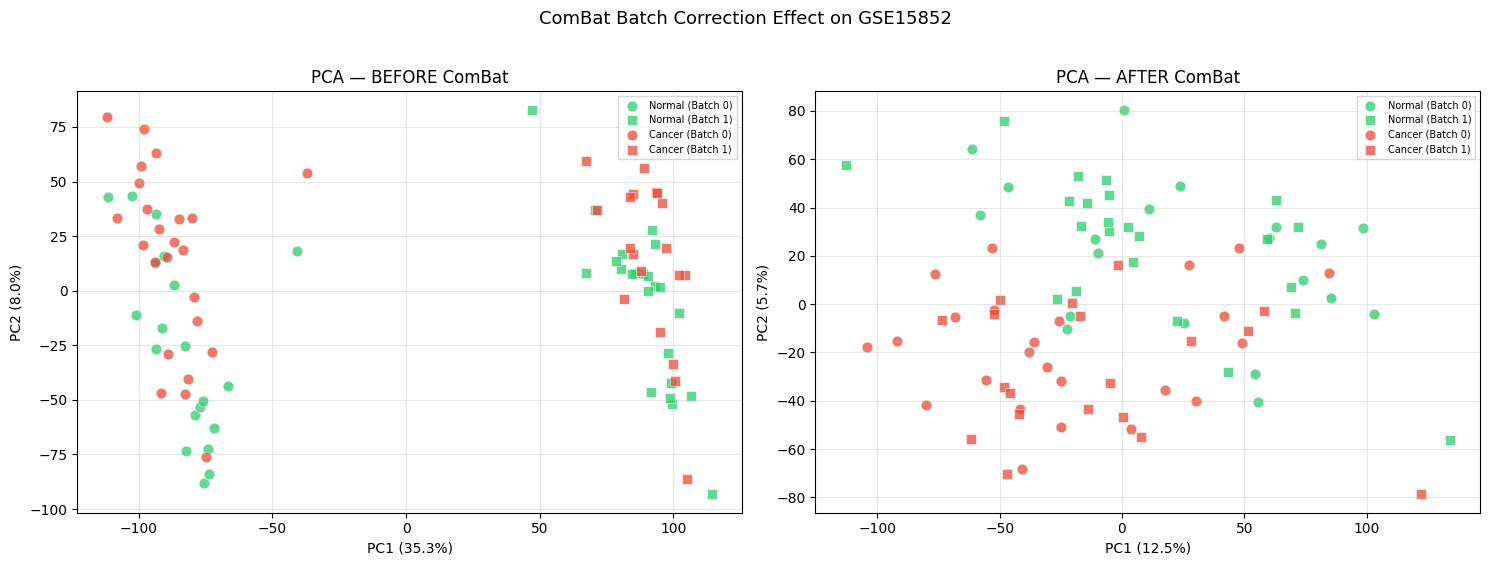

In [7]:
#Before after plot on PCA Scatter
fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))

labels_tissue = np.where(y == 0, 'Normal', 'Cancer')
batch_arr = np.array(batch)
marker_map = {0: 'o', 1: 's'}  # circle = Batch_0, square = Batch_1
color_map  = {'Normal': '#2ecc71', 'Cancer': '#e74c3c'}

for ax_i, (scores, var_ratio, title_tag) in enumerate([
    (_pre_combat_pca,  _pre_combat_var,  'BEFORE ComBat'),
    (_post_combat_pca, _post_combat_var, 'AFTER ComBat'),
]):
    ax = axes[ax_i]
    for tissue in ['Normal', 'Cancer']:
        for b in [0, 1]:
            mask = (labels_tissue == tissue) & (batch_arr == b)
            if mask.sum() == 0:
                continue
            ax.scatter(
                scores[mask, 0], scores[mask, 1],
                c=color_map[tissue],
                marker=marker_map[b],
                label=f'{tissue} (Batch {b})',
                s=60, alpha=0.75, edgecolors='white', lw=0.5,
            )
    ax.set_xlabel(f'PC1 ({var_ratio[0]*100:.1f}%)')
    ax.set_ylabel(f'PC2 ({var_ratio[1]*100:.1f}%)')
    ax.set_title(f'PCA — {title_tag}')
    ax.legend(fontsize=7, frameon=True)
    ax.grid(True, alpha=0.3)

fig.suptitle('ComBat Batch Correction Effect on GSE15852', fontsize=13, y=1.02)
fig.tight_layout()
plt.show()

# Clean up temporary variables
del _scaler_tmp, _X_tmp, _pca_tmp, _pca_scores
del _scaler_post, _X_post, _pca_post
del _pre_combat_pca, _pre_combat_var, _post_combat_pca, _post_combat_var


As you can observe, the **AFTER** set has much clearer sepration between data

## Unsupervised Variance PRE-FILTER

In a mircroarray data the vast majority of signals show little to no variation. This means they hold no discriminatory information but still massively inflate the feature space, degrading actual information within the data. We run the risk of picking up random noise rather than real biological signals.

A simple approach is to remove the bottom 50% of probes by variance.

This filter is strictly unsupervised though, it uses only probe variance and never looks at the labels itself.

For `reference` study used:  Kallah-Dagadu et al. (2025). Using machine learning to improve cancer diagnosis accuracy through genetic data analysis. International Journal of Applied Mathematics.

-In this study they used a much more strict 75% pass filter.

In [8]:
feature_variances = X_df.var(axis=0)            #variance per probe
variance_threshold = feature_variances.median() #median = 50th percentile

#keep only probes whose variance exceeds the median
keep_mask = feature_variances >= variance_threshold
X_filtered = X_df.loc[:, keep_mask]

print("VARIANCE PRE-FILTER (unsupervised)")
print(f"Features before filter : {X_df.shape[1]:,}")
print(f"Variance threshold     : {variance_threshold:.6f}  (median)")
print(f"Features after filter  : {X_filtered.shape[1]:,}")
print(f"Features removed       : {(~keep_mask).sum():,}  (bottom 50 %)")

VARIANCE PRE-FILTER (unsupervised)
Features before filter : 22,283
Variance threshold     : 0.332885  (median)
Features after filter  : 11,142
Features removed       : 11,141  (bottom 50 %)


In [ ]:
#Standardize
#LASSO expects standardized datasets (it will mathematically work still though) unscaled datasets will
#suffer from scales getting too large and creating a much more punishing model
#all it does is add noise, as such scaling is mandatory for LASSO to work as expected.

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_filtered)

print(f"Standardised matrix shape: {X_scaled.shape}")

#scaled data should have 0 mean and 1 SD
print(f"Mean ~ 0 check (first 5 cols): {X_scaled.mean(axis=0)[:5].round(6)}")
print(f"Std  ~ 1 check (first 5 cols): {X_scaled.std(axis=0)[:5].round(6)}")


Standardised matrix shape: (86, 11142)
Mean ~ 0 check (first 5 cols): [ 0.  0.  0. -0.  0.]
Std  ~ 1 check (first 5 cols): [1. 1. 1. 1. 1.]


In [10]:
#Secondary PCA Diagnostic Post-Scaling 
pca_full = PCA(n_components=min(20, X_scaled.shape[0]))
X_pca = pca_full.fit_transform(X_scaled)

explained = pca_full.explained_variance_ratio_
cumulative = np.cumsum(explained)

print(f"PC1 explains {explained[0]*100:.1f}% of variance")
print(f"PC2 explains {explained[1]*100:.1f}% of variance")
print(f"PC1+PC2 cumulative: {cumulative[1]*100:.1f}%")
print(f"Components needed for 80% variance: {np.searchsorted(cumulative, 0.80) + 1}")

PC1 explains 10.8% of variance
PC2 explains 6.4% of variance
PC1+PC2 cumulative: 17.2%
Components needed for 80% variance: 21


The 21 Value is good, before adding the variance check, earlier attempts at this data also yielded 21 Principal Components, this mean that internally, the data has not been affected and discrimnimatory information remains within. 

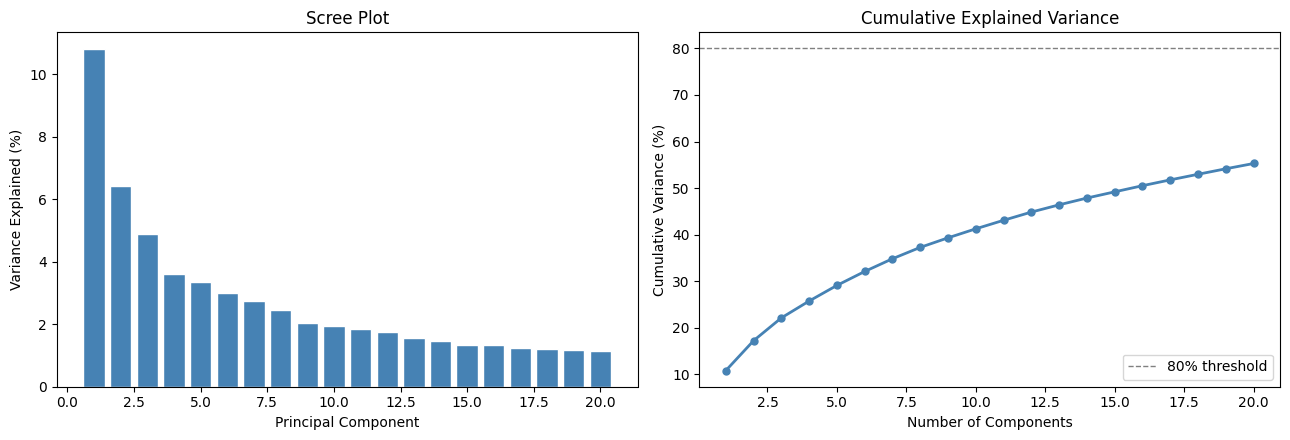

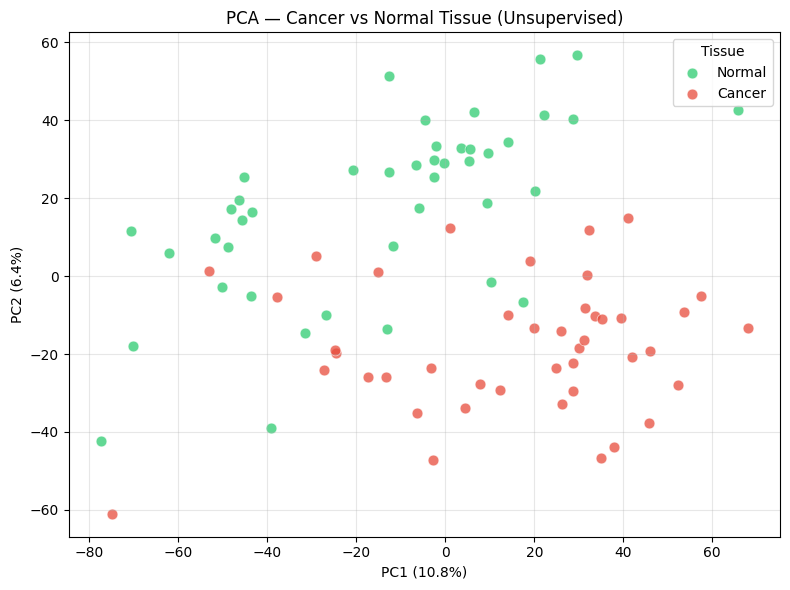

In [11]:
# scree plot
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].bar(range(1, len(explained)+1), explained * 100,
            color='steelblue', edgecolor='white')
axes[0].set_xlabel('Principal Component')
axes[0].set_ylabel('Variance Explained (%)')
axes[0].set_title('Scree Plot')

axes[1].plot(range(1, len(cumulative)+1), cumulative * 100,
             'o-', color='steelblue', lw=2, markersize=5)
axes[1].axhline(80, ls='--', color='grey', lw=1, label='80% threshold')
axes[1].set_xlabel('Number of Components')
axes[1].set_ylabel('Cumulative Variance (%)')
axes[1].set_title('Cumulative Explained Variance')
axes[1].legend()
fig.tight_layout()
plt.show()

# PCA scatter
labels_str = np.where(y == 0, 'Normal', 'Cancer')
colors_map = {'Normal': '#2ecc71', 'Cancer': '#e74c3c'}

fig, ax = plt.subplots(figsize=(8, 6))
for label in ['Normal', 'Cancer']:
    mask = labels_str == label
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1],
               c=colors_map[label], label=label, s=60,
               alpha=0.75, edgecolors='white', lw=0.5)
ax.set_xlabel(f'PC1 ({explained[0]*100:.1f}%)')
ax.set_ylabel(f'PC2 ({explained[1]*100:.1f}%)')
ax.set_title('PCA — Cancer vs Normal Tissue (Unsupervised)')
ax.legend(title='Tissue', frameon=True)
ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()

## LASSO CV

We are using Lasso Cross Validation, this means it uses splits/folds of our data and performs validation on one while using the rest as train. We use cv = 10 (amount of folds) to ensure it gets much more granularity when its attempting to find `optimal alpha`   

In [12]:
lasso = LassoCV(cv=10, random_state=42, max_iter=10_000)
lasso.fit(X_scaled, y)

n_features_alpha_min = int((lasso.coef_ != 0).sum())
print(f"Optimal alpha (alpha_min): {lasso.alpha_:.6f}")
print(f"Non-zero features at alpha_min: {n_features_alpha_min} out of {len(lasso.coef_)}")

Optimal alpha (alpha_min): 0.091535
Non-zero features at alpha_min: 16 out of 11142


## Dynamic Standard Error Fallback

Our `Optimal Alpha` is not quite exact yet, though it does pick the alpha with the lowest mean squared error `MSE` we can tone its gene sparsity even MORE. 

This is by moving our alpha and checking if its MSE is still within 1 Standard Error. This makes the model more strict but still maintain a relatively close MSE score. The larger the alpha, the sparser the model, making results more more interpretable.

**core idea**

threshold = mse_min + (multiplier x se_min)

In high-dimensional settings with few samples, the SE bands can be so wide that the 1-SE alpha produces 0 features.  To handle this we use a*dynamic multiplier*: start at 1.0 and progressively reduce to 0.75, 0.50, 0.25 until the selected alpha yields a clinically viable signature (between 15 and 30 features).  If none work, fall back to alpha_min.

For `referece` used: Schemet, L., & Friedrich-Welz, S. (2026). Statistical inference after variable selection in Cox models: A simulation study (arXiv:2602.07477v1). arXiv.

-They noted usage of 1-SE method as a viable choice for alpha adjustment, relatively conservative but does lead to sparser models.

In [13]:
#extract the MSE path from LassoCV  (shape: n_alphas × n_folds)
mean_mse = np.mean(lasso.mse_path_, axis=1)
std_mse  = np.std(lasso.mse_path_, axis=1)
n_folds  = lasso.mse_path_.shape[1]

# standard error = std / sqrt(n_folds)
se_mse = std_mse / np.sqrt(n_folds)

# identify the minimum MSE and its SE
idx_min   = np.argmin(mean_mse)
mse_min   = mean_mse[idx_min]
se_min    = se_mse[idx_min]
alpha_min = lasso.alphas_[idx_min]

# targets for a clinically viable signature
MIN_FEATURES = 15
MAX_FEATURES = 30
MIN_FEATURES_HARD = 10    # absolute floor before reducing multiplier

# dynamic SE-multiplier cascade
multipliers = [1.0, 0.75, 0.50, 0.25]
chosen_alpha      = None
chosen_n_features = None
chosen_multiplier = None

for mult in multipliers:
    threshold = mse_min + mult * se_min

    # find the largest alpha whose mean MSE ≤ threshold.
    # lasso.alphas_ is sorted descending (largest first), so the first
    # alpha that satisfies the condition is the most parsimonious.
    candidate_alpha = None
    for i, a in enumerate(lasso.alphas_):
        if mean_mse[i] <= threshold:
            candidate_alpha = a
            break               # first hit = largest qualifying alpha

    if candidate_alpha is None:
        # mo alpha satisfies this threshold — try a smaller multiplier
        continue

    # fit a Lasso at the candidate alpha and count features
    model_1se = Lasso(alpha=candidate_alpha, max_iter=10_000)
    model_1se.fit(X_scaled, y)
    n_feat = int((model_1se.coef_ != 0).sum())

    # check against the hard floor
    if n_feat >= MIN_FEATURES_HARD:
        chosen_alpha      = candidate_alpha
        chosen_n_features = n_feat
        chosen_multiplier = mult
        # if within the ideal range, stop immediately
        if MIN_FEATURES <= n_feat <= MAX_FEATURES:
            break
        # otherwise, keep searching with a smaller multiplier for a
        # better (more features) result

# fallback: if no multiplier produced ≥ MIN_FEATURES_HARD features,
# use alpha_min itself
if chosen_alpha is None:
    chosen_alpha      = alpha_min
    chosen_multiplier = 0.0   # indicates fallback
    model_1se = Lasso(alpha=chosen_alpha, max_iter=10_000)
    model_1se.fit(X_scaled, y)
    chosen_n_features = int((model_1se.coef_ != 0).sum())

adjusted_1se_alpha = chosen_alpha

In [14]:
print("DYNAMIC 1-SE ALPHA SELECTION SUMMARY")
print(f"MSE at alpha_min         : {mse_min:.6f}")
print(f"SE  at alpha_min         : {se_min:.6f}")
print(f"SE multiplier used       : {chosen_multiplier}")
print(f"1-SE threshold (MSE)     : {mse_min + chosen_multiplier * se_min:.6f}")
print()
print(f"alpha_min                : {alpha_min:.6f}  →  {n_features_alpha_min} features")
print(f"adjusted_1se_alpha       : {adjusted_1se_alpha:.6f}  →  {chosen_n_features} features")
print(f"Alpha multiplier (ratio) : {adjusted_1se_alpha / alpha_min:.2f}x")

DYNAMIC 1-SE ALPHA SELECTION SUMMARY
MSE at alpha_min         : 0.089011
SE  at alpha_min         : 0.011772
SE multiplier used       : 0.75
1-SE threshold (MSE)     : 0.097839

alpha_min                : 0.091535  →  16 features
adjusted_1se_alpha       : 0.129748  →  15 features
Alpha multiplier (ratio) : 1.42x


Not much changed but this was more of a sanity check to see if we can push the amount of viable genes even lower

In [ ]:
coef_1se = pd.Series(model_1se.coef_, index=X_filtered.columns, name="coefficient")
nonzero_1se = coef_1se[coef_1se != 0].copy()
nonzero_1se = nonzero_1se.reindex(nonzero_1se.abs().sort_values(ascending=False).index)

panel = nonzero_1se.to_frame()
panel.index.name = "Probe_ID"
panel["abs_coefficient"] = panel["coefficient"].abs()
panel["direction"] = np.where(panel["coefficient"] > 0, "up in cancer", "down in cancer")
panel["rank"] = range(1, len(panel) + 1)

y_pred_1se = (model_1se.predict(X_scaled) > 0.5).astype(int)
acc_1se = accuracy_score(y, y_pred_1se)

print(f"Adjusted 1-SE LASSO selected {len(panel)} biomarker probes")
#for accuracy IN TRAIN SET (not reliable and very easy to cheat out)
print(f"Training accuracy:  {acc_1se:.4f}")

#R^2 or Coefficient Of Determination is a strength of evidence metric, or how closely our gene expression levels
#actually correlate with the probability of having cancer
print(f"R² (in-sample):     {model_1se.score(X_scaled, y):.4f}")
print(f"BIOMARKER PANEL ({len(panel)} probes,  alpha = {adjusted_1se_alpha:.6f})")
print(panel.to_string())

Adjusted 1-SE LASSO selected 15 biomarker probes
Training accuracy:  0.9884
R² (in-sample):     0.7299
  BIOMARKER PANEL (15 probes,  alpha = 0.129748)
             coefficient  abs_coefficient       direction  rank
Probe_ID                                                       
202988_s_at     0.107421         0.107421    up in cancer     1
266_s_at        0.046359         0.046359    up in cancer     2
205478_at      -0.040493         0.040493  down in cancer     3
210964_s_at    -0.028225         0.028225  down in cancer     4
219738_s_at    -0.024749         0.024749  down in cancer     5
209686_at      -0.022883         0.022883  down in cancer     6
221009_s_at    -0.022633         0.022633  down in cancer     7
203549_s_at    -0.016621         0.016621  down in cancer     8
206243_at      -0.016493         0.016493  down in cancer     9
209550_at      -0.010068         0.010068  down in cancer    10
212112_s_at    -0.006171         0.006171  down in cancer    11
219398_at      -

Coefficient represents the given `weight` from the LASSO model, direction tells the push it gives towards the answer.

In [20]:
coef_series = pd.Series(lasso.coef_, index=X_filtered.columns, name="coefficient")
nonzero = coef_series[coef_series != 0].copy()
nonzero = nonzero.reindex(nonzero.abs().sort_values(ascending=False).index)

print(f"Total probes:           {len(coef_series):,}")
print(f"Non-zero (alpha_min):   {len(nonzero):,}")
print(f"Zeroed-out (excluded):  {(coef_series == 0).sum():,}")
print()

#top 20 but with the stuff we did earlier its down to just 16
top20 = nonzero.head(20).to_frame()
top20.index.name = "Probe_ID"
top20["abs_coefficient"] = top20["coefficient"].abs()
top20["direction"] = np.where(top20["coefficient"] > 0, "up in cancer", "down in cancer")

print("  TOP 20 alpha_min BIOMARKER PROBES (for comparison)")
print(top20.to_string())
print()

Total probes:           11,142
Non-zero (alpha_min):   16
Zeroed-out (excluded):  11,126

  TOP 20 alpha_min BIOMARKER PROBES (for comparison)
             coefficient  abs_coefficient       direction
Probe_ID                                                 
202988_s_at     0.119943         0.119943    up in cancer
221009_s_at    -0.043403         0.043403  down in cancer
219738_s_at    -0.036630         0.036630  down in cancer
205478_at      -0.035116         0.035116  down in cancer
266_s_at        0.034729         0.034729    up in cancer
209686_at      -0.033483         0.033483  down in cancer
212112_s_at    -0.021937         0.021937  down in cancer
206243_at      -0.016477         0.016477  down in cancer
203549_s_at    -0.016464         0.016464  down in cancer
202014_at      -0.014822         0.014822  down in cancer
201650_at       0.014259         0.014259    up in cancer
213275_x_at     0.012896         0.012896    up in cancer
218124_at      -0.012003         0.012003  do

In [ ]:
r2 = model_1se.score(X_scaled, y)
y_pred = (model_1se.predict(X_scaled) > 0.5).astype(int)
acc = accuracy_score(y, y_pred)


#More precise statistics for the model
print(f"R² score (in-sample):       {r2:.4f}")
print(f"Training accuracy:          {acc:.4f}")
print(f"Adjusted 1-SE alpha:        {adjusted_1se_alpha:.6f}")
print(f"Non-zero / Total features:  {chosen_n_features} / {len(model_1se.coef_)}")
print()
print(classification_report(y, y_pred, target_names=['Normal', 'Cancer']))

R² score (in-sample):       0.7299
Training accuracy:          0.9884
Adjusted 1-SE alpha:        0.129748
Non-zero / Total features:  15 / 11142

              precision    recall  f1-score   support

      Normal       1.00      0.98      0.99        43
      Cancer       0.98      1.00      0.99        43

    accuracy                           0.99        86
   macro avg       0.99      0.99      0.99        86
weighted avg       0.99      0.99      0.99        86



A visualization of MSE as we adjusted ALPHA

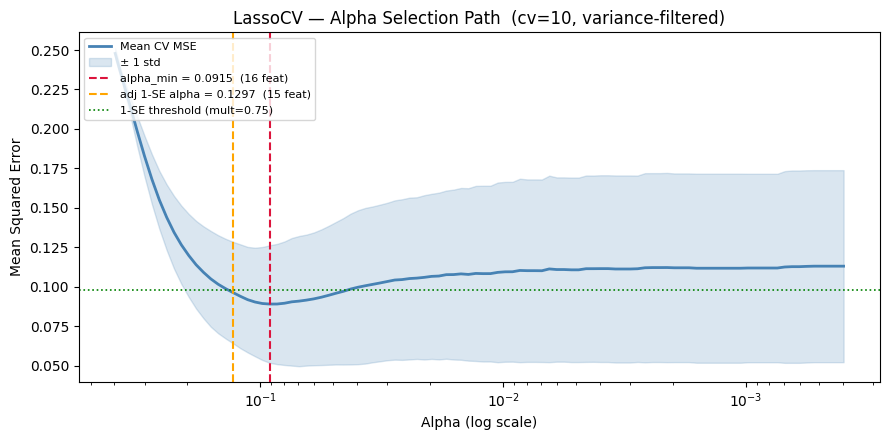

In [18]:
# Alpha-path MSE curve 
fig, ax = plt.subplots(figsize=(9, 4.5))

ax.semilogx(lasso.alphas_, mean_mse, color='steelblue', lw=2,
            label='Mean CV MSE')
ax.fill_between(lasso.alphas_, mean_mse - std_mse, mean_mse + std_mse,
                alpha=0.2, color='steelblue', label='± 1 std')

# Mark alpha_min
ax.axvline(alpha_min, color='crimson', ls='--', lw=1.5,
           label=f'alpha_min = {alpha_min:.4f}  ({n_features_alpha_min} feat)')

# Mark adjusted 1-SE alpha
ax.axvline(adjusted_1se_alpha, color='orange', ls='--', lw=1.5,
           label=f'adj 1-SE alpha = {adjusted_1se_alpha:.4f}  ({chosen_n_features} feat)')

# Horizontal threshold line
threshold_val = mse_min + chosen_multiplier * se_min
ax.axhline(threshold_val, color='green', ls=':', lw=1.2,
           label=f'1-SE threshold (mult={chosen_multiplier})')

ax.set_xlabel('Alpha (log scale)')
ax.set_ylabel('Mean Squared Error')
ax.set_title('LassoCV — Alpha Selection Path  (cv=10, variance-filtered)')
ax.legend(fontsize=8, loc='upper left')
ax.invert_xaxis()
fig.tight_layout()
plt.show()


## Saving the Model for External Validation

We use joblib since we dont expect to use this model outside of python environments

In [19]:
#build the list of retained Probe_IDs (non-zero coefficients)
retained_features = list(X_filtered.columns[model_1se.coef_ != 0])

#save to disk
EXPORT_DIR = "exported_model"
import os
os.makedirs(EXPORT_DIR, exist_ok=True)

joblib.dump(scaler,             os.path.join(EXPORT_DIR, "training_scaler.joblib"))
joblib.dump(model_1se,          os.path.join(EXPORT_DIR, "lasso_1se_model.joblib"))
joblib.dump(retained_features,  os.path.join(EXPORT_DIR, "retained_features.joblib"))

print("EXPORTED TRAINING ARTIFACTS")
print(f"Scaler       → {os.path.join(EXPORT_DIR, 'training_scaler.joblib')}")
print(f"Lasso model  → {os.path.join(EXPORT_DIR, 'lasso_1se_model.joblib')}")
print(f"Feature list → {os.path.join(EXPORT_DIR, 'retained_features.joblib')}")
print(f"# of features: {len(retained_features)}")
print(f"Features     : {retained_features}")

EXPORTED TRAINING ARTIFACTS
Scaler       → exported_model\training_scaler.joblib
Lasso model  → exported_model\lasso_1se_model.joblib
Feature list → exported_model\retained_features.joblib
# of features: 15
Features     : ['201650_at', '202014_at', '202988_s_at', '203549_s_at', '205478_at', '206243_at', '209550_at', '209686_at', '210964_s_at', '212112_s_at', '218124_at', '219398_at', '219738_s_at', '221009_s_at', '266_s_at']


In [25]:
#Probe ID → Gene Symbol mapping (GPL96 / HG-U133A)
#(this is the chip used in GSE15852 — Affymetrix HG-U133A)

annot = pd.read_csv(
    "exported_model/GPL96-57554.txt",
    sep="\t",
    comment="#",
    low_memory=False,
)

annot = annot.set_index("ID")["Gene Symbol"]

# Map gene symbols onto the biomarker panel
panel["Gene_Symbol"] = panel.index.map(annot)

print("  BIOMARKER PANEL — GENE MAPPING")
print(panel[["coefficient", "direction", "Gene_Symbol"]].to_string())
print()



  BIOMARKER PANEL — GENE MAPPING
             coefficient       direction Gene_Symbol
Probe_ID                                            
202988_s_at     0.107421    up in cancer        RGS1
266_s_at        0.046359    up in cancer        CD24
205478_at      -0.040493  down in cancer     PPP1R1A
210964_s_at    -0.028225  down in cancer        GYG2
219738_s_at    -0.024749  down in cancer       PCDH9
209686_at      -0.022883  down in cancer       S100B
221009_s_at    -0.022633  down in cancer     ANGPTL4
203549_s_at    -0.016621  down in cancer         LPL
206243_at      -0.016493  down in cancer       TIMP4
209550_at      -0.010068  down in cancer         NDN
212112_s_at    -0.006171  down in cancer       STX12
219398_at      -0.005725  down in cancer       CIDEC
201650_at       0.005291    up in cancer       KRT19
218124_at      -0.003286  down in cancer      RETSAT
202014_at      -0.000324  down in cancer    PPP1R15A

